In [1]:
!wget https://raw.githubusercontent.com/Alireza-Akhavan/deeplearning-tensorflow2-notebooks/master/dataset.py
!wget https://github.com/Alireza-Akhavan/deeplearning-tensorflow2-notebooks/raw/master/dataset/Data_hoda_full.mat -P dataset

--2026-06-23 19:11:29--  https://raw.githubusercontent.com/Alireza-Akhavan/deeplearning-tensorflow2-notebooks/master/dataset.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 917 [text/plain]
Saving to: ‘dataset.py.1’

dataset.py.1        100%[===================>]     917  --.-KB/s    in 0s      

2026-06-23 19:11:29 (29.3 MB/s) - ‘dataset.py.1’ saved [917/917]

--2026-06-23 19:11:29--  https://github.com/Alireza-Akhavan/deeplearning-tensorflow2-notebooks/raw/master/dataset/Data_hoda_full.mat
Resolving github.com (github.com)... 140.82.121.3
Connecting to github.com (github.com)|140.82.121.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/Alireza-Akhavan/deeplearning-tensorflow2-notebooks/mas

In [1]:
import os

print(os.getcwd())
print(os.listdir())

/mnt/e/Deep Learning/src/Model Subclassing - Autoencoders - Generative Adversarial Networks (GANs)
['AutoEncoder_anomaly.ipynb', 'Convolotional_AutoEncoder.ipynb', 'Introduction_to_Autoencoders.ipynb', 'Simple_GAN.ipynb', 'Upsampling_AytoEncoder.ipynb', 'U_Net.ipynb', 'wget-log']


In [2]:
import sys
sys.path.append("/mnt/e/Deep Learning")

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input, Activation, LeakyReLU

from data.dataset import load_hoda

In [4]:
X_train, y_train, X_test, y_test = load_hoda()

In [5]:
X_train.shape

(60000, 28, 28)

In [6]:
X_train[0]

array([[  0,   0,   0,   0,   0, 109, 255, 255, 109,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 172, 247, 255, 255, 247, 172,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,  66, 232, 248, 255, 255, 255, 255, 182,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  66, 232, 232,
        133,   0],
       [  0, 127, 232, 255, 255, 255, 255, 255, 127,  23,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0, 127, 232, 255, 255,
        241, 223],
       [  0, 146, 255, 255, 255, 255, 224,  71,  18,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,  31, 183, 237, 255, 255, 255,
        163,  41],
       [  0, 146, 255, 255, 255, 167,  43,   7,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,  88, 212, 248, 255, 255, 255, 255,
        146,   0],
       [19

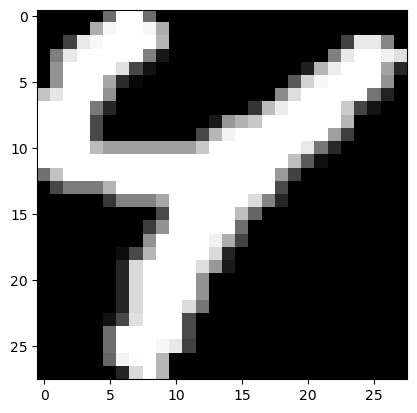

In [7]:
plt.imshow(X_train[0], cmap='gray')

In [8]:

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape : (0,)
y_test shape : (0,)


In [9]:
set(y_train)

{np.uint8(0),
 np.uint8(1),
 np.uint8(2),
 np.uint8(3),
 np.uint8(4),
 np.uint8(5),
 np.uint8(6),
 np.uint8(7),
 np.uint8(8),
 np.uint8(9)}

In [10]:
np.random.seed(42)
randomDIM = 100

In [12]:
X_train = np.astype(X_train, np.float32)
X_train = X_train - 127.5 / 127.5   #(-1, 1)
X_train = X_train.reshape((-1, 28*28))

print(X_train.shape)

(60000, 784)


# Create Generator

In [ ]:
gen_model = Sequential()
gen_model.add(Input(shape=(randomDIM,)))
gen_model.add(Dense(256, kernel_initializer=tf.keras.initializers.RandomNormal(mean=0, stddev=0.02)))
gen_model.add(LeakyReLU(negative_slope=0.2))
gen_model.add(Dense(512))
gen_model.add(LeakyReLU(0.2))
gen_model.add(Dense(1024))
gen_model.add(LeakyReLU(0.2))
gen_model.add(Dense(724, activation='tanh'))